# Randomness and Bayesian Inverse Problems
**Inverse Problems and Imaging (02624) — Week 6**

*Kim Knudsen with Claude, October 7, 2026*

So far the noise $e$ in $y = Ax^* + e$ was a fixed, unknown vector with $\|e\|\le\delta$. This week we model uncertainty with random variables:

1. **Bias and variance.** Only the noise is random. The Tikhonov solution $x_\alpha$ then becomes a random variable, and its error splits into bias and variance.
2. **The Bayesian inverse problem.** The noise is random, and the unknown $x$ is given a prior random distribution. The solution of the inverse problem is a probability distribution, the **posterior**.
3. **Estimators.** How to extract point estimates (MAP, CM) and uncertainty from the posterior.
4. **The Gaussian case.** With a Gaussian prior and likelihood, everything can be computed by hand. We meet Tikhonov regularization again and see that the choice of regularization matrix is a choice of prior.

Throughout, priors and noise are **Gaussian**. Other models, and the computational tools they require, are mentioned in the outlook.

**Reading:** Kaipio & Somersalo, *Statistical and Computational Inverse Problems* (2005), Sections 3–3.2.1 (pp. 49–58) and 3.4 (pp. 72–79).

The code in this notebook only draws illustrations. Run the setup cell below once; you do not need to read it.

In [1]:
# ---------- Setup: imports, Abel test problem, plotting helpers (run once) ----------
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import beta

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(2025)

def abel_matrix(N):
    # y(t) = int_0^t x(s)/sqrt(t-s) ds, piecewise constant x, collocation at t_i = i*h
    h = 1.0 / N
    i = np.arange(1, N + 1)[:, None]; j = np.arange(1, N + 1)[None, :]
    return np.where(j <= i, 2 * (np.sqrt(np.maximum(i - j + 1, 0) * h)
                                 - np.sqrt(np.maximum(i - j, 0) * h)), 0.0)

N, nu = 256, 1.5
s = (np.arange(1, N + 1) - 0.5) / N          # midpoints
t = np.arange(1, N + 1) / N                  # collocation points
A = abel_matrix(N)
x_true = s**nu                               # x*(s) = s^nu
y_true = A @ x_true                          # y* = A x*   (close to t^(nu+1/2) B(1+nu,1/2))
U, S, Vt = np.linalg.svd(A)

def R(alpha):
    # Tikhonov reconstruction operator R_alpha = (A^T A + alpha I)^{-1} A^T
    return Vt.T @ np.diag(S / (S**2 + alpha)) @ U.T

def levels(f):
    # contour levels at 0.5, 1, ..., 3 'standard deviations' below the peak
    return np.sort(f.max() * np.exp(-0.5 * np.arange(0.5, 3.01, 0.5)**2))

print("Abel problem ready: N =", N, ", condition number of A =", round(S[0] / S[-1], 1))

Abel problem ready: N = 256 , condition number of A = 15.4


---
## 1. Bias and variance

### 1.1 Setting
Today we consider only finite dimensional problems with a model given by the matrix $A.$ We observe
$$
y = y^* + e = Ax^* + e ,
$$
where $x^*$ is the (deterministic) true solution and $e$ is the noise. We reconstruct with Tikhonov regularization,
$$
x_\alpha = R_\alpha y,\qquad R_\alpha = (A^TA+\alpha I)^{-1}A^T .
$$
By linearity the reconstruction and its error split into two parts:
$$
x_\alpha = R_\alpha A x^* + R_\alpha e,
\qquad
x^* - x_\alpha = \underbrace{(I-R_\alpha A)\,x^*}_{\text{bias}} \;-\; \underbrace{R_\alpha e}_{\text{perturbation error}} .
$$
As $\alpha\to 0$ the bias vanishes while the perturbation error grows; for large $\alpha$ it is the other way round (recall why). The perturbation error depends on the particular $e$. To make statements that do not depend on one unknown vector, we model $e$ as a random variable.

### 1.2 Noise as a random variable
Regard $e$ as one realization of a random vector $E=(E_1,\dots,E_m)$. The basic model is i.i.d. Gaussian noise,
$$
E_j \overset{\text{iid}}{\sim}\mathcal{N}(0,\sigma^2) \quad\Longleftrightarrow\quad E\sim\mathcal{N}(0,\sigma^2 I).
$$
More generally $E\sim\mathcal{N}(e_0,\Gamma)$ with mean $e_0\in\mathbb R^m$ and symmetric positive definite covariance $\Gamma$. Its density is
$$
\pi_E(e) = \frac{1}{(2\pi)^{m/2}|\Gamma|^{1/2}}\exp\!\Big(-\tfrac12(e-e_0)^T\Gamma^{-1}(e-e_0)\Big),
\qquad P(E\in B)=\int_B\pi_E(e)\,de .
$$

**Relation to the noise level $\delta$.** If $E\sim\mathcal{N}(0,\sigma^2 I_m)$ then $\mathbb E\|E\|_2^2 = \sum_j \mathbb E E_j^2 = m\sigma^2$, and $\|E\|_2$ concentrates around $\sigma\sqrt m$ for large $m$. So the deterministic noise level corresponds to $\delta\approx\sigma\sqrt m$ (absolute) or $\delta\approx\sigma\sqrt m/\|y^*\|$ (relative).

### 1.3 The Tikhonov solution is a random variable

From multivariate statistics we know that a linear transformation of a Gaussian random variable is Gaussian; more specifically if $E\sim\mathcal{N}(e_0,\Gamma)$ and $M$ is a matrix, then $ME + b\sim\mathcal{N}(Me_0+b,\;M\Gamma M^T)$.

With $X_\alpha = R_\alpha(y^*+E)$ and $E\sim\mathcal{N}(0,\sigma^2 I)$ this gives

> **Proposition.**
> $$X_\alpha \sim \mathcal{N}\big(R_\alpha A x^*,\; \sigma^2 R_\alpha R_\alpha^T\big).$$

* The **mean** $R_\alpha A x^*$ is not $x^*$: Tikhonov is a *biased* estimator. As $\alpha\to 0$ the bias decreases.
* The **covariance** $\sigma^2R_\alpha R_\alpha^T$ describes the spread over noise realizations. As $\alpha\to 0$ the variance increases.

### 1.4 Bias–variance decomposition

> **Theorem.** For $E\sim\mathcal{N}(0,\sigma^2 I)$,
> $$
> \mathbb E\,\|X_\alpha - x^*\|^2 \;=\; \underbrace{\|(I-R_\alpha A)x^*\|^2}_{\text{bias}^2} \;+\; \underbrace{\sigma^2\,\mathrm{tr}(R_\alpha R_\alpha^T)}_{\text{variance}} .
> $$

*Proof.* Write $X_\alpha - x^* = -b + R_\alpha E$ with the deterministic $b=(I-R_\alpha A)x^*$. Then
$\mathbb E\|X_\alpha-x^*\|^2 = \|b\|^2 - 2\,b^T R_\alpha\mathbb E[E] + \mathbb E\|R_\alpha E\|^2$. The middle term vanishes since $\mathbb E[E]=0$, and
$\mathbb E\|R_\alpha E\|^2 = \mathbb E\,\mathrm{tr}(R_\alpha EE^TR_\alpha^T) = \mathrm{tr}(R_\alpha\,\sigma^2 I\,R_\alpha^T)$. $\square$

**In terms of the SVD** $A=\sum_i s_i u_iv_i^T$, with filter factors $\varphi_i = s_i^2/(s_i^2+\alpha)$:
$$
\text{bias}^2 = \sum_i (1-\varphi_i)^2\,(v_i^Tx^*)^2 = \sum_i\Big(\frac{\alpha}{s_i^2+\alpha}\Big)^2(v_i^Tx^*)^2,
\qquad
\text{variance} = \sigma^2\sum_i \frac{s_i^2}{(s_i^2+\alpha)^2}.
$$
From these formulas: the bias is increasing in $\alpha$ and tends to $0$ as $\alpha\to0$; the variance is decreasing in $\alpha$ and tends to $\sigma^2\sum_i s_i^{-2}$ as $\alpha\to0$. That limit is huge when $A$ has small singular values: the ill-posedness reappears as variance.

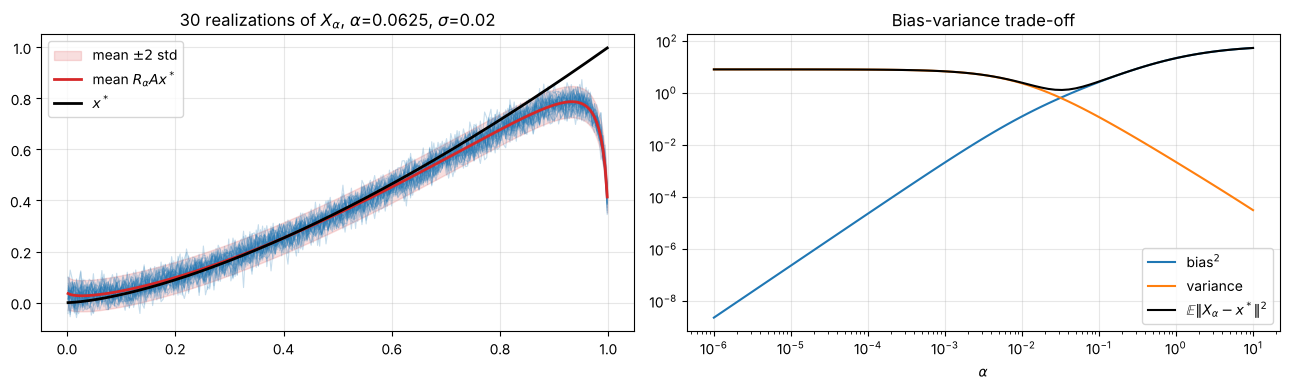

In [2]:
# Figure 1: the distribution of x_alpha (left) and the bias-variance trade-off (right)
sigma, alpha = 0.02, 0.0625
Ra = R(alpha)
X = Ra @ (y_true[:, None] + sigma * rng.standard_normal((N, 30)))   # 30 noise realizations
std = sigma * np.sqrt(np.sum(Ra**2, axis=1))

alphas = np.logspace(-6, 1, 80)
c = Vt @ x_true                                                      # v_i^T x*
bias2 = np.array([np.sum((a / (S**2 + a))**2 * c**2) for a in alphas])
var = np.array([sigma**2 * np.sum(S**2 / (S**2 + a)**2) for a in alphas])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(s, X, color="C0", alpha=0.25, lw=0.8)
ax[0].fill_between(s, Ra @ y_true - 2*std, Ra @ y_true + 2*std, color="C3", alpha=0.15,
                   label=r"mean $\pm2$ std")
ax[0].plot(s, Ra @ y_true, "C3", lw=2, label=r"mean $R_\alpha Ax^*$")
ax[0].plot(s, x_true, "k", lw=2, label=r"$x^*$")
ax[0].set_title(fr"30 realizations of $X_\alpha$, $\alpha$={alpha}, $\sigma$={sigma}"); ax[0].legend()
ax[1].loglog(alphas, bias2, label=r"bias$^2$")
ax[1].loglog(alphas, var, label="variance")
ax[1].loglog(alphas, bias2 + var, "k", label=r"$\mathbb{E}\|X_\alpha-x^*\|^2$")
ax[1].set_xlabel(r"$\alpha$"); ax[1].legend(); ax[1].set_title("Bias-variance trade-off")
plt.tight_layout(); plt.show()

Note the systematic deviation of the mean from $x^*$ near $s=1$ (bias) and the band of realizations around the mean (variance).

---
## 2. The Bayesian inverse problem

In Section 1 only the noise was random, while $x^*$ was a fixed unknown vector. The Bayesian approach goes one step further: **every quantity we are uncertain about is modelled as a random variable**, including the unknown. We write $X$ for the unknown, $E$ for the noise and $Y$ for the data, and use the model
$$
Y = AX + E ,\qquad X \text{ and } E \text{ independent}.
$$

### 2.1 Bayes' formula
The whole approach rests on one formula (Kaipio & Somersalo, Theorem 3.1). Given the observed data $y_{\text{obs}}$,
$$
\underbrace{\pi(x\mid y_{\text{obs}})}_{\text{posterior}}
= \frac{\overbrace{\pi(y_{\text{obs}}\mid x)}^{\text{likelihood}}\;\overbrace{\pi_{\text{pr}}(x)}^{\text{prior}}}{\underbrace{\pi(y_{\text{obs}})}_{\text{normalization}}} .
$$

* **Prior** $\pi_{\text{pr}}(x)$: a probability density on $\mathbb R^n$ describing our knowledge of the unknown *before* observing data.
* **Likelihood** $\pi(y_{\text{obs}}\mid x)$: how probable the observed data are if the unknown is $x$. It is built from the forward model and the noise model (Section 2.2).
* **Posterior** $\pi(x\mid y_{\text{obs}})$: a probability density on $\mathbb R^n$ describing our knowledge of the unknown *after* observing $y_{\text{obs}}$.
* **Normalization** $\pi(y_{\text{obs}}) = \int\pi(y_{\text{obs}}\mid x)\pi_{\text{pr}}(x)\,dx$ is a number that does not depend on $x$. We usually only need
$$
\pi(x\mid y_{\text{obs}})\;\propto\;\pi(y_{\text{obs}}\mid x)\,\pi_{\text{pr}}(x).
$$

Where the formula comes from is recalled in Section 2.5.

### 2.2 Noise distribution and likelihood: keep them apart
Three different functions are easily confused. They are built from the same ingredients but live on different spaces.

**(i) The noise density** $\pi_E(e)$, $e\in\mathbb R^m$. It describes the measurement error alone and contains neither $x$ nor data. Example: $E\sim\mathcal{N}(0,\sigma^2I)$, $\pi_E(e)\propto\exp\big(-\|e\|^2/(2\sigma^2)\big)$.

**(ii) The likelihood as a conditional density** $\pi(y\mid x)$, $y\in\mathbb R^m$, for a *fixed* $x$. It is the distribution of the data we would observe if the unknown were $x$.

> **Proposition** (Kaipio & Somersalo, Section 3.2.1). If $Y = AX+E$ with $X$ and $E$ independent, then
> $$\pi(y\mid x) = \pi_E(y - Ax).$$

*Argument.* Conditioned on $X=x$, the term $Ax$ is a fixed vector and, by independence, $E$ still has density $\pi_E$. So $Y = Ax+E$ is $E$ translated by $Ax$, and the density of a translate is the translated density. $\square$

For Gaussian noise: $E\sim\mathcal{N}(0,\sigma^2I)$ gives $Y\mid X=x\;\sim\;\mathcal{N}(Ax,\sigma^2I)$. The likelihood has the same shape as the noise density, but is centred at $Ax$ instead of $0$. For every fixed $x$ it is a probability density in $y$: $\int_{\mathbb R^m}\pi(y\mid x)\,dy = 1$.

**(iii) The likelihood function** $x\mapsto\pi(y_{\text{obs}}\mid x)$, with the data *fixed* at $y_{\text{obs}}$. This is what enters Bayes' formula. It is a function on $\mathbb R^n$, but **it is not a probability density in $x$**: its integral over $x$ need not be $1$, and may be infinite.
* If $A$ is square and invertible, substituting $e = y_{\text{obs}}-Ax$ gives $\int\pi_E(y_{\text{obs}}-Ax)\,dx = 1/|\det A|$.
* If $A$ has a nontrivial null space, then $\pi(y_{\text{obs}}\mid x+z) = \pi(y_{\text{obs}}\mid x)$ for every $z\in\mathcal N(A)$, so the integral is $+\infty$. The data alone say nothing about the null-space component.

Only after multiplication by the prior do we obtain a density in $x$, the posterior.

| function | variable | held fixed | probability density in |
|---|---|---|---|
| noise density $\pi_E(e)$ | $e\in\mathbb R^m$ | — | $e$ |
| likelihood $\pi(y\mid x)=\pi_E(y-Ax)$ | $y\in\mathbb R^m$ | $x$ | $y$ |
| likelihood function $x\mapsto\pi(y_{\text{obs}}\mid x)$ | $x\in\mathbb R^n$ | $y_{\text{obs}}$ | not a density |
| prior $\pi_{\text{pr}}(x)$ | $x\in\mathbb R^n$ | — | $x$ |
| posterior $\pi(x\mid y_{\text{obs}})$ | $x\in\mathbb R^n$ | $y_{\text{obs}}$ | $x$ |

**Warning.** One often writes $\pi(y_{\text{obs}}\mid x) = \pi_E(e)$. This is correct only when read as *the noise density evaluated at the residual* $e = y_{\text{obs}}-Ax$, which is a function of $x$. The noise model determines the likelihood, but the two are different objects: change $A$ and the likelihood changes, while the noise density does not. (The formula $\pi(y\mid x)=\pi_E(y-Ax)$ also relies on the noise being additive and independent of $X$; other noise models are mentioned in the outlook.)

### 2.3 The solution of the inverse problem

> **The solution of the Bayesian inverse problem is the posterior distribution $\pi(x\mid y_{\text{obs}})$**: the distribution of possible solutions $x$, given the prior and the data. It is not a single vector.

* Even when $Ax=y$ is ill-posed, the posterior is typically a well-defined distribution that depends continuously on the data. In this sense **Bayesian inverse problems are most often well-posed**. The instability has not disappeared: it shows up as large posterior uncertainty in directions the data do not determine.

**Why go Bayesian?** Classical regularization already gives good reconstructions, so what do we gain?
* **Uncertainty quantification.** Instead of one reconstruction we get a distribution over solutions, and with it error bars, credible intervals, and answers to questions like "how probable is it that $x$ exceeds a threshold in this region?". For decisions based on a reconstruction (medical, geophysical, engineering), the uncertainty is often as important as the estimate.
* **The prior makes modelling explicit.** A regularization term becomes a statement about what we believe about the unknown. Knowledge about the unknown is encoded in a principled way.
* **One framework for everything uncertain.** Noise models, unknown parameters such as the noise level or the regularization strength, and even modelling errors are handled with the same tool: they become random variables, and Bayes' formula tells us how data update them.

### 2.4 A picture in two dimensions
Take $x\in\mathbb R^2$ and a nearly singular $A = \begin{pmatrix}1&1\\1&1.2\end{pmatrix}$, prior $\mathcal{N}(0,0.6^2I)$, noise $\mathcal{N}(0,0.1^2I)$. In two dimensions we can evaluate everything on a grid. All three panels are plotted as functions of $x$. The middle panel is the likelihood *function* $x\mapsto\pi(y_{\text{obs}}\mid x)$, scaled to have maximum $1$; it is not a density in $x$.

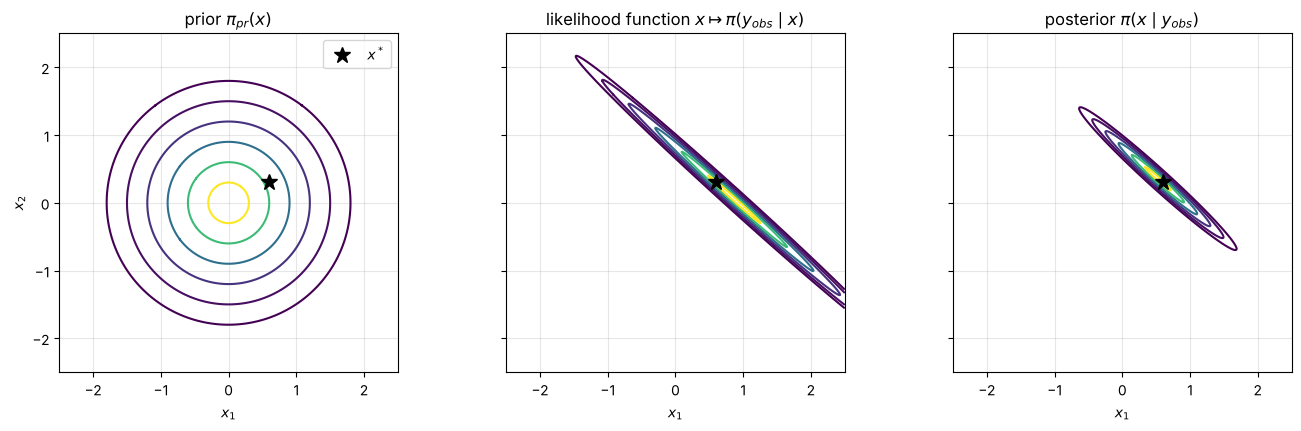

In [3]:
# Figure 2: prior x likelihood function -> posterior in 2D
A2 = np.array([[1.0, 1.0], [1.0, 1.2]])
x2_true, sig2, gam2 = np.array([0.6, 0.3]), 0.1, 0.6
y2_obs = A2 @ x2_true + np.array([0.02, -0.03])          # one fixed noise realization

g = np.linspace(-2.5, 2.5, 501); dg = g[1] - g[0]
P1, P2 = np.meshgrid(g, g, indexing="ij"); pts = np.stack([P1.ravel(), P2.ravel()])
def normalize(logp):
    p = np.exp(logp - logp.max()); return p / (p.sum() * dg**2)

log_prior = (-0.5 * np.sum(pts**2, 0) / gam2**2).reshape(P1.shape)
log_like = (-0.5 * np.sum((y2_obs[:, None] - A2 @ pts)**2, 0) / sig2**2).reshape(P1.shape)
prior, post = normalize(log_prior), normalize(log_prior + log_like)   # densities in x
like = np.exp(log_like - log_like.max())          # likelihood FUNCTION of x, scaled to max 1 (not a density in x)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.3), sharey=True)
for a_, f, ttl in zip(ax, [prior, like, post],
                      [r"prior $\pi_{pr}(x)$", r"likelihood function $x\mapsto\pi(y_{obs}\mid x)$",
                       r"posterior $\pi(x\mid y_{obs})$"]):
    a_.contour(P1, P2, f, levels(f)); a_.plot(*x2_true, "k*", ms=12, label="$x^*$")
    a_.set_title(ttl); a_.set_aspect("equal"); a_.set_xlabel("$x_1$")
ax[0].set_ylabel("$x_2$"); ax[0].legend()
plt.tight_layout(); plt.show()

The **likelihood function** alone is a long ridge: the data determine $x_1+x_2$ well but not $x_1-x_2$ (this is the ill-posedness). Here $\det A = 0.2$, so the likelihood function integrates to $1/|\det A| = 5$ over $\mathbb R^2$, not $1$; for a singular $A$ the ridge would be infinitely long and not integrable at all. Multiplying by the **prior** cuts the ridge off, and the **posterior** is a bounded probability density concentrated near $x^*$.

### 2.5 Probability theory revisited: where Bayes' formula comes from

A random variable $X$ in $\mathbb R^n$ has a distribution $\mu_X$ and, when it exists, a density $\pi_X$:
$$
P(X\in B) = \mu_X(B) = \int_B\pi_X(x)\,dx .
$$
*Example:* $X\sim\mathcal{N}(0,1)$ has $\pi_X(x) = (2\pi)^{-1/2}e^{-x^2/2}$ and $P(X\in(a,b)) = \int_a^b\pi_X(x)\,dx$.

For two random variables $(X_1,X_2)$ with joint density $\pi(x_1,x_2)$:

* **Joint:** $P(X_1\in B_1\text{ and }X_2\in B_2) = \displaystyle\int_{B_1}\int_{B_2}\pi(x_1,x_2)\,dx_2\,dx_1$.
* **Marginal:** $\mu_{X_1}(B_1) = \mu_{X_1,X_2}(B_1\times\mathbb R^{n_2})$, with density $\pi(x_1) = \displaystyle\int_{\mathbb R^{n_2}}\pi(x_1,x_2)\,dx_2$.
* **Conditional:** for events, $P(B_1\mid B_2) = P(B_1\cap B_2)/P(B_2)$. For densities,
$$
\mu(B_1\mid x_2) = \int_{B_1}\frac{\pi(x_1,x_2)}{\pi(x_2)}\,dx_1,
\qquad\text{so}\qquad
\pi(x_1\mid x_2) = \frac{\pi(x_1,x_2)}{\pi(x_2)}\quad(\pi(x_2)>0).
$$

> **Bayes' formula.** Since $\pi(x_1\mid x_2)\,\pi(x_2) = \pi(x_1,x_2) = \pi(x_2\mid x_1)\,\pi(x_1)$,
> $$\pi(x_1\mid x_2) = \frac{\pi(x_2\mid x_1)\,\pi(x_1)}{\pi(x_2)} .$$

(A rigorous treatment, with conditioning on events of probability zero such as $\{X_2 = x_2\}$, requires measure theory.)

Putting $x_1 = x$ and $x_2 = y_{\text{obs}}$ gives the formula of Section 2.1: the posterior is the conditional density of $X$ given $Y=y_{\text{obs}}$, and the likelihood is the conditional density of $Y$ given $X=x$, evaluated at $y=y_{\text{obs}}$.

---
## 3. Estimators: exploring the posterior

The posterior is a distribution on $\mathbb R^n$, typically with $n$ large. To report a result we summarize it.

### 3.1 Point estimates
> **Maximum a posteriori (MAP) estimate**
> $$x_{\text{MAP}} = \arg\max_{x\in\mathbb R^n}\pi(x\mid y_{\text{obs}}).$$
> **Conditional mean (CM) estimate**
> $$x_{\text{CM}} = \mathbb E[X\mid y_{\text{obs}}] = \int_{\mathbb R^n} x\,\pi(x\mid y_{\text{obs}})\,dx.$$

* $x_{\text{MAP}}$ is the *most probable* value. Computing it is an **optimization** problem, often equivalent to minimizing $-\log\pi(x\mid y_{\text{obs}})$.
* $x_{\text{CM}}$ is the *average* over all possible solutions. Computing it is an **integration** problem in $n$ dimensions.

**Why the conditional mean?** It is the best estimate in mean square, given the data:

> **Proposition.** $x_{\text{CM}}$ minimizes $\hat x\mapsto\mathbb E\big[\|X-\hat x\|^2\,\big|\,y_{\text{obs}}\big]$.

*Proof.* Write $X-\hat x = (X-x_{\text{CM}}) + (x_{\text{CM}}-\hat x)$ and expand. The cross term is $2(x_{\text{CM}}-\hat x)^T\,\mathbb E[X-x_{\text{CM}}\mid y_{\text{obs}}] = 0$, so
$\mathbb E[\|X-\hat x\|^2\mid y_{\text{obs}}] = \mathbb E[\|X-x_{\text{CM}}\|^2\mid y_{\text{obs}}] + \|x_{\text{CM}}-\hat x\|^2$, which is smallest for $\hat x = x_{\text{CM}}$. $\square$

### 3.2 Uncertainty
A point estimate throws away what makes the Bayesian approach useful. From the posterior we also get
* the **posterior covariance** $\Gamma_{\text{post}} = \mathrm{Cov}(X\mid y_{\text{obs}})$, and the pointwise standard deviations $\sqrt{(\Gamma_{\text{post}})_{ii}}$;
* **credible intervals**, i.e. intervals containing $X_i$ with a given posterior probability. For a Gaussian posterior $\mathcal{N}(\bar x,\Gamma_{\text{post}})$ the $95\%$ interval is $\bar x_i \pm 1.96\sqrt{(\Gamma_{\text{post}})_{ii}}$.

For a **Gaussian** posterior both estimators are available in closed form and coincide: the density is largest at its mean, so $x_{\text{MAP}} = x_{\text{CM}} = \bar x$. Section 4 computes $\bar x$ and $\Gamma_{\text{post}}$ explicitly.

---
## 4. The Gaussian case: prior and likelihood

### 4.1 Gaussian prior and Gaussian noise
Assume $Y = AX+E$ with $X$ and $E$ independent and
$$
X\sim\mathcal{N}(0,\gamma^2 I)\quad\text{(prior)},\qquad E\sim\mathcal{N}(0,\sigma^2 I)\quad\text{(noise)}.
$$
* **Prior:** $\displaystyle\pi_{\text{pr}}(x)\propto\exp\Big(-\frac{\|x\|^2}{2\gamma^2}\Big)$. It says the components of $x$ are independent and of size about $\gamma$, and nothing more (no smoothness, for instance).
* **Noise:** $\displaystyle\pi_E(e)\propto\exp\Big(-\frac{\|e\|^2}{2\sigma^2}\Big)$, a density on $\mathbb R^m$.
* **Likelihood** (Section 2.2): $Y\mid X=x\sim\mathcal{N}(Ax,\sigma^2I)$, that is $\displaystyle\pi(y\mid x) = \pi_E(y-Ax)\propto\exp\Big(-\frac{\|y-Ax\|^2}{2\sigma^2}\Big)$, a density in $y$.
* **Likelihood function:** with the data fixed, $\displaystyle x\mapsto\pi(y_{\text{obs}}\mid x)\propto\exp\Big(-\frac{\|Ax-y_{\text{obs}}\|^2}{2\sigma^2}\Big)$. This is what enters Bayes' formula.

### 4.2 The posterior is Gaussian
By Bayes' formula,
$$
\pi(x\mid y_{\text{obs}})\propto\exp\Big(-\frac{1}{2\sigma^2}\Big[\|Ax-y_{\text{obs}}\|^2 + \alpha\|x\|^2\Big]\Big),
\qquad \alpha = \frac{\sigma^2}{\gamma^2}.
$$
The exponent is quadratic in $x$. Expanding,
$$
\|Ax-y_{\text{obs}}\|^2+\alpha\|x\|^2 = x^T(A^TA+\alpha I)x - 2x^TA^Ty_{\text{obs}} + \text{const},
$$
and completing the square gives

> **Theorem** (cf. Kaipio & Somersalo, Theorem 3.7). The posterior is $\mathcal{N}(\bar x,\Gamma_{\text{post}})$ with
> $$
> \bar x = (A^TA+\alpha I)^{-1}A^Ty_{\text{obs}} = R_\alpha y_{\text{obs}},
> \qquad
> \Gamma_{\text{post}} = \sigma^2(A^TA+\alpha I)^{-1},
> \qquad \alpha=\frac{\sigma^2}{\gamma^2}.
> $$

Kaipio & Somersalo state the same result in the equivalent form
$\bar x = \gamma^2A^T(\gamma^2AA^T+\sigma^2I)^{-1}y_{\text{obs}}$ and
$\Gamma_{\text{post}} = \gamma^2I-\gamma^4A^T(\gamma^2AA^T+\sigma^2I)^{-1}A$
(the two forms can be shown to agree using the SVD of $A$).

**Consequences**
* $x_{\text{MAP}} = x_{\text{CM}} = \bar x = R_\alpha y_{\text{obs}}$: **the Tikhonov solution is the MAP (and CM) estimate** for a Gaussian prior and Gaussian noise.
* The regularization parameter gets an interpretation: $\alpha = \sigma^2/\gamma^2$ is a noise-to-prior variance ratio. More noise, or a tighter prior, means stronger regularization.
* The Bayesian approach gives more than Tikhonov: the covariance $\Gamma_{\text{post}}$ quantifies how uncertain the reconstruction is.

### 4.3 Tikhonov in Section 1 versus the posterior: two different questions
Both Section 1 and Section 4.2 produce a Gaussian centred at a Tikhonov solution, so it is easy to mix them up. They answer different questions:

| | Section 1: distribution of the estimator | Section 4: posterior |
|---|---|---|
| unknown $x$ | fixed $x^*$ | random, $X\sim\mathcal{N}(0,\gamma^2 I)$ |
| data | random, $Y = Ax^*+E$ | fixed, the observed $y_{\text{obs}}$ |
| question | how does $x_\alpha$ vary over repeated experiments? | what do we know about $x$ given *this* $y_{\text{obs}}$? |
| mean | $R_\alpha A x^*$ (unknown, contains $x^*$) | $R_\alpha y_{\text{obs}}$ (computable) |
| covariance | $\sigma^2 R_\alpha R_\alpha^T$ | $\Gamma_{\text{post}}=\sigma^2(A^TA+\alpha I)^{-1}$ |

The covariances are **not** the same. The posterior covariance is larger, because it also accounts for not knowing $x$, i.e. for the bias. This can be made precise:

> **Proposition.** If $X\sim\mathcal{N}(0,\gamma^2I)$ and $E\sim\mathcal{N}(0,\sigma^2I)$ are independent and $\alpha=\sigma^2/\gamma^2$, then the error of the Tikhonov estimator $R_\alpha Y$ has covariance
> $$
> \mathrm{Cov}\big(X - R_\alpha Y\big) = \underbrace{\gamma^2(I-R_\alpha A)(I-R_\alpha A)^T}_{\text{bias, averaged over the prior}} + \underbrace{\sigma^2R_\alpha R_\alpha^T}_{\text{variance}} = \Gamma_{\text{post}} .
> $$

*Proof.* $X - R_\alpha Y = (I-R_\alpha A)X - R_\alpha E$, a sum of two independent Gaussians, so the covariances add (Section 1.3). To see that the sum equals $\Gamma_{\text{post}}$, use the SVD: in the basis $v_i$ both sides are diagonal, and
$$
\gamma^2\Big(\frac{\alpha}{s_i^2+\alpha}\Big)^2 + \sigma^2\frac{s_i^2}{(s_i^2+\alpha)^2}
= \frac{\sigma^2\alpha + \sigma^2 s_i^2}{(s_i^2+\alpha)^2} = \frac{\sigma^2}{s_i^2+\alpha},
$$
using $\gamma^2\alpha^2 = \sigma^2\alpha$. $\square$

So the bias–variance decomposition of Section 1 and the Bayesian posterior fit together: **the posterior covariance is "bias² + variance", with the bias averaged over the prior.** The spread of $R_\alpha(y^*+e)$ over noise realizations captures only the variance part; it is *not* the posterior.

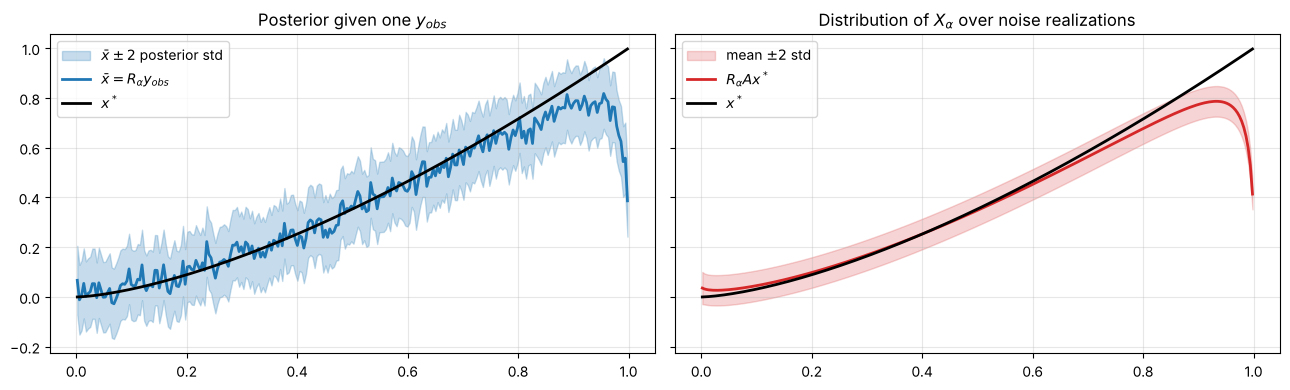

alpha = 0.0625,  average posterior std = 0.0708,  average estimator std = 0.0307,  prior std = 0.08


In [4]:
# Figure 4: Abel problem. Posterior (left) vs distribution of the Tikhonov estimator (right)
sigma, gamma = 0.02, 0.08
alpha = sigma**2 / gamma**2
y_obs = y_true + sigma * rng.standard_normal(N)

Ra = R(alpha)
x_bar = Ra @ y_obs                                                    # posterior mean = MAP
post_std = sigma * np.sqrt(np.sum(Vt**2 / (S**2 + alpha)[:, None], axis=0))   # sqrt diag Gamma_post
est_std = sigma * np.sqrt(np.sum(Ra**2, axis=1))                      # sqrt diag sigma^2 R R^T

fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
ax[0].fill_between(s, x_bar - 2*post_std, x_bar + 2*post_std, color="C0", alpha=0.25,
                   label=r"$\bar x\pm2$ posterior std")
ax[0].plot(s, x_bar, "C0", lw=2, label=r"$\bar x=R_\alpha y_{obs}$")
ax[0].plot(s, x_true, "k", lw=2, label="$x^*$")
ax[0].set_title(r"Posterior given one $y_{obs}$"); ax[0].legend()
ax[1].fill_between(s, Ra @ y_true - 2*est_std, Ra @ y_true + 2*est_std, color="C3", alpha=0.2,
                   label=r"mean $\pm2$ std")
ax[1].plot(s, Ra @ y_true, "C3", lw=2, label=r"$R_\alpha Ax^*$")
ax[1].plot(s, x_true, "k", lw=2, label="$x^*$")
ax[1].set_title(r"Distribution of $X_\alpha$ over noise realizations"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"alpha = {alpha},  average posterior std = {post_std.mean():.4f},  "
      f"average estimator std = {est_std.mean():.4f},  prior std = {gamma}")

**Things to notice**
* The posterior band is wider than the estimator band, as the proposition predicts.
* Near $s=1$ the band does not cover $x^*$. Compare the size of $x^*$ (values up to 1) with what the prior $\mathcal{N}(0,0.08^2I)$ considers plausible. A Bayesian answer is only as good as its prior.

This is a problem with the **prior**, not with $\alpha$: $\mathcal{N}(0,\gamma^2I)$ says the components of $x$ are independent and small, and nothing more. Within the Gaussian framework, the remedy is a better prior covariance and possibly a nonzero prior mean, which is the topic of the next section.

### 4.4 The general Gaussian case: priors are regularization matrices
Now let the prior and noise be general Gaussians, independent of each other:
$$
X\sim\mathcal{N}(x_0,\Gamma_{\text{pr}}),\qquad E\sim\mathcal{N}(e_0,\Gamma_{\text{noise}}).
$$
Factor the inverse covariances (e.g. by Cholesky) as $\Gamma_{\text{noise}}^{-1} = L_E^TL_E$ and $\Gamma_{\text{pr}}^{-1} = L_X^TL_X$. Exactly as in 4.2, the negative log-posterior is quadratic:
$$
-\log\pi(x\mid y_{\text{obs}}) = \tfrac12\|L_E(Ax + e_0 - y_{\text{obs}})\|^2 + \tfrac12\|L_X(x-x_0)\|^2 + \text{const}.
$$

> **Theorem** (Kaipio & Somersalo, Theorem 3.7). The posterior is $\mathcal{N}(\bar x,\Gamma_{\text{post}})$ with
> $$
> \Gamma_{\text{post}} = \big(A^T\Gamma_{\text{noise}}^{-1}A + \Gamma_{\text{pr}}^{-1}\big)^{-1},
> \qquad
> \bar x = \Gamma_{\text{post}}\big(A^T\Gamma_{\text{noise}}^{-1}(y_{\text{obs}}-e_0) + \Gamma_{\text{pr}}^{-1}x_0\big),
> $$
> equivalently $\bar x = x_0 + \Gamma_{\text{pr}}A^T(A\Gamma_{\text{pr}}A^T+\Gamma_{\text{noise}})^{-1}(y_{\text{obs}}-Ax_0-e_0)$, and $x_{\text{MAP}} = x_{\text{CM}} = \bar x$ is the minimizer of
> $$
> \|L_E(Ax + e_0 - y_{\text{obs}})\|^2 + \|L_X(x-x_0)\|^2 .
> $$

This is **generalized Tikhonov regularization**, and each ingredient you know from earlier weeks now has a probabilistic meaning:

| Tikhonov ingredient | Bayesian meaning |
|---|---|
| regularization matrix $L$ in $\alpha\|Lx\|^2$ | prior covariance: $\Gamma_{\text{pr}} = \gamma^2(L^TL)^{-1}$ |
| reference solution $x_0$ in $\|L(x-x_0)\|^2$ | prior mean |
| regularization parameter $\alpha$ | $\sigma^2/\gamma^2$ when $\Gamma_{\text{noise}}=\sigma^2I$, $\Gamma_{\text{pr}}=\gamma^2(L^TL)^{-1}$ |
| weighted data misfit $\|L_E(Ax-y)\|^2$ | correlated or non-uniform noise ("whitening") |
| subtracting a known offset from the data | noise mean $e_0$ |

**Whitening.** Multiplying $Y = AX+E$ by $L_E$ gives $L_E(Y-e_0) = (L_EA)X + L_E(E-e_0)$, and $L_E(E-e_0)\sim\mathcal{N}(0,L_E\Gamma_{\text{noise}}L_E^T) = \mathcal{N}(0,I)$. Correlated noise is thus reduced to white noise by a change of variables in data space.

**Choosing a prior = choosing $L$.** The table works in both directions: every regularization matrix $L$ you have used corresponds to a Gaussian prior, and every Gaussian prior covariance corresponds to a regularization matrix. A derivative-type $L$, for instance, penalizes oscillations, so the corresponding prior favours smooth $x$ (Kaipio & Somersalo, Section 3.4.1). The prior covariance is where knowledge about the unknown enters, and it often matters more than the precise value of $\alpha$.

*Caution:* $L$ must be invertible for $\Gamma_{\text{pr}} = \gamma^2(L^TL)^{-1}$ to exist. If $L$ has a null space (a pure difference matrix does not penalize constants), the "prior" is not a probability density (an *improper* prior).

---
## 5. Outlook: beyond the Gaussian case
Everything in this notebook could be computed by hand because prior and noise were Gaussian and the forward model linear: the posterior was again Gaussian, given by a mean and a covariance. The Bayesian framework is much more general.

* **Other priors.** Smoothness priors built from difference matrices (Kaipio & Somersalo, Section 3.4.1), edge-preserving priors such as total variation, sparsity-promoting priors (e.g. Laplace/$\ell^1$), positivity constraints, and Markov random fields (Section 3.3).
* **Other likelihoods.** When the noise is not additive, the likelihood is not $\pi_E(y-Ax)$ and must be derived from the measurement process. For photon counts, $Y_j\mid X=x\sim\mathrm{Poisson}\big((Ax)_j\big)$ and $\pi(y\mid x) = \prod_j \frac{(Ax)_j^{y_j}}{y_j!}e^{-(Ax)_j}$ (Sections 3.2.2–3.2.3).
* **Non-Gaussian posteriors.** The posterior may be skewed or have several modes. Then MAP and CM need not coincide, the MAP may fail to exist or be unique, and the CM can even lie in a region of low posterior probability (Section 3.1.1 and Figure 3.2).
* **Exploring the posterior.** Without a closed form, the conditional mean, credible intervals and other summaries are high-dimensional integrals. They are computed by **sampling**, typically Markov chain Monte Carlo (Section 3.6). This is the topic of the research lecture on **CUQI — Computational Uncertainty Quantification for Inverse Problems**.
* **Unknown parameters.** If $\sigma$ or $\gamma$ (and hence $\alpha$) are unknown, they can be modelled as random and inferred together with $x$ (hierarchical models, Section 3.7).
* A rigorous treatment, especially in infinite dimensions, requires measure theory. Bayesian inverse problems are most often well-posed in this setting too.